# Notebook to align AX3 accelerometer measurements with audio recorded tap hit sequence

In [73]:
import sys
import os
import time
import datetime as dt
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from IPython.display import Audio
import mir_eval.sonify


from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [119]:
%load_ext autoreload
%autoreload 1
%aimport al

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [142]:
%reload_ext autoreload

## Load data and timing details

audio file (ZOOM0019_LR.WAV): 
 - Sync 1,  34.319 s, 13:48 local time
 - clapper 1, 2437.788 s,
 - Stimulus (applause), 2505.937s
 - Stimulus (music), 2528.285
 - Stimulus (applause 2), 2822.525
 - clapper 2, 2850.388 s,
 - clapper 3, 2853.664 s
 - Sync 2, 4214.149 s


In [76]:
sync1_start = pd.to_datetime('2025-09-30 13:48:00.000+0200') # as reported to the sync spider
sync_start 

Timestamp('2025-09-30 13:48:00+0200', tz='UTC+02:00')

# Extract sync cues from accompanying audio recording

In [154]:
audio_file ='../Raw/ZOOM0019_LR.WAV'
y, sr = librosa.load(audio_file)
file1_len = len(y)
cues= {}

198450


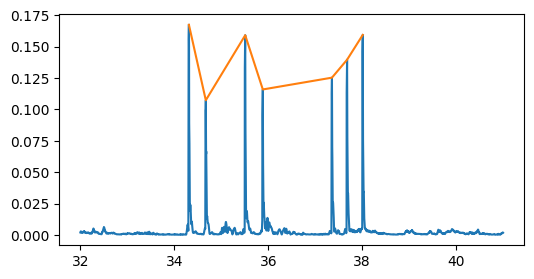

,rms,peaks,DateTime
32.000000,0.001962,0,2025-09-30 13:48:32+02:00
32.002902,0.002395,0,2025-09-30 13:48:32.002902494+02:00
32.005805,0.002703,0,2025-09-30 13:48:32.005804989+02:00
32.008707,0.002713,0,2025-09-30 13:48:32.008707483+02:00
32.011610,0.002548,0,2025-09-30 13:48:32.011609977+02:00
...,...,...,...
40.986122,0.001687,0,2025-09-30 13:48:40.986122449+02:00
40.989025,0.001895,0,2025-09-30 13:48:40.989024943+02:00
40.991927,0.001920,0,2025-09-30 13:48:40.991927438+02:00
40.994830,0.001943,0,2025-09-30 13:48:40.994829932+02:00


In [155]:
cue_delay = 32 # seconds  34.319 
cue_start = cue_delay*sr
cue_end = cue_start + 9*sr
cue = y[cue_start:cue_end]
print(len(cue))

cue_df = al.local_max_max(cue,np.round(cue_delay,3),sr,thresh = 0.98)
cue_df['rms'].plot(figsize=(6,3))
cue_df.loc[cue_df['peaks']==1,'rms'].plot()
plt.show()
cue_df['DateTime'] = sync_start + pd.to_timedelta(cue_df.index,unit='s')
cue_df

In [156]:
cues['Sync1'] = cue_df.copy()
cue_df.to_csv('./outfiles/cue1.csv')


176400


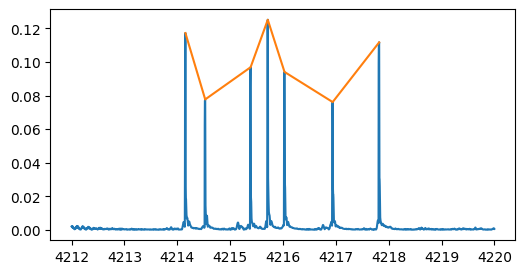

,rms,peaks,DateTime
4212.000000,0.002095,0,2025-09-30 14:58:12+02:00
4212.002902,0.002259,0,2025-09-30 14:58:12.002902494+02:00
4212.005805,0.002271,0,2025-09-30 14:58:12.005804989+02:00
4212.008707,0.001663,0,2025-09-30 14:58:12.008707483+02:00
4212.011610,0.001522,0,2025-09-30 14:58:12.011609977+02:00
...,...,...,...
4219.987664,0.000875,0,2025-09-30 14:58:19.987664399+02:00
4219.990567,0.000919,0,2025-09-30 14:58:19.990566893+02:00
4219.993469,0.000922,0,2025-09-30 14:58:19.993469388+02:00
4219.996372,0.000812,0,2025-09-30 14:58:19.996371882+02:00


In [157]:
cue_delay = 4212# seconds  4214.149
cue_start = cue_delay*sr
cue_end = cue_start + 8*sr
cue = y[cue_start:cue_end]
print(len(cue))

cue_df = al.local_max_max(cue,np.round(cue_delay,3),sr,thresh = 0.98)
cue_df['rms'].plot(figsize=(6,3))
cue_df.loc[cue_df['peaks']==1,'rms'].plot()
plt.show()
cue_df['DateTime'] = sync_start + pd.to_timedelta(cue_df.index,unit='s')
cue_df

In [158]:
cues['Sync2'] = cue_df.copy()
cue_df.to_csv('./outfiles/cue2.csv')

In [159]:
sf = 400 
synch_times = {}
CueT = {}

In [163]:
np.linspace(t_range[0],t_range[1],sf*(t_range[1]-t_range[0]),endpoint=False)
peaks[0]

796

34.310385    0.0000
34.670295    0.3599
35.509116    1.1987
35.883537    1.5731
37.355102    3.0447
37.677279    3.3669
38.011066    3.7007
Name: SyncTime, dtype: float64


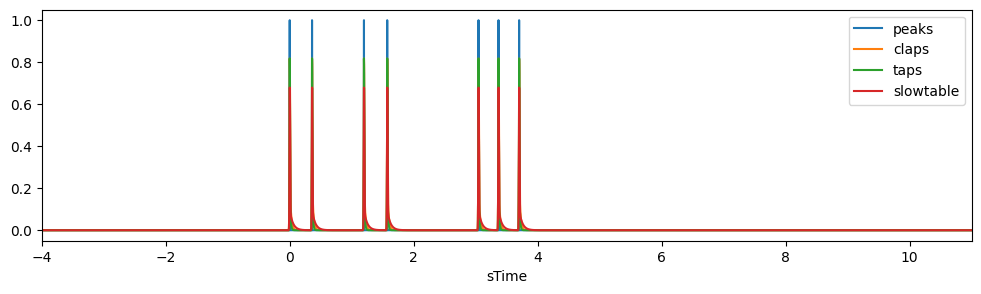

In [164]:
cue_times = cues['Sync1'].copy()
cue_times['DateTime'] = pd.to_datetime(cue_times['DateTime'],format='ISO8601')
cue_times['S_AudioTime'] = np.round(cue_times.index,4)
Sync_Zero_Time_s = cue_times.loc[cue_times['peaks']==1,'S_AudioTime'].iloc[0]
Sync_Zero_Time_dt = cue_times.loc[cue_times['peaks']==1,'DateTime'].iloc[0].tz_localize(None) 
synch_times['cue1'] = Sync_Zero_Time_dt
cue_times['SyncTime'] = cue_times['S_AudioTime']-Sync_Zero_Time_s # zero on onset of first synch cue
peak_times = cue_times.loc[cue_times['peaks']==1,'SyncTime']
print(peak_times)
t_range= [-4,11]
cue = al.cue_template_make(peak_times,sf,t_range)
cue.plot(x='sTime',y=['peaks','claps','taps','slowtable'],figsize=[12,3])
plt.xlim(t_range)

CueT['cue1'] = cue

4214.153651    0.0000
4214.528073    0.3744
4215.387211    1.2335
4215.712290    1.5586
4216.028662    1.8750
4216.940045    2.7863
4217.819501    3.6658
Name: SyncTime, dtype: float64


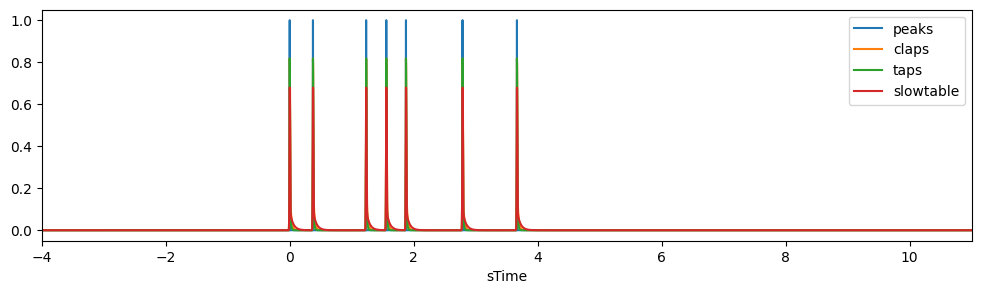

In [165]:
cue_times = cues['Sync2'].copy()
cue_times['DateTime'] = pd.to_datetime(cue_times['DateTime'],format='ISO8601')
cue_times['S_AudioTime'] = np.round(cue_times.index,4)
Sync_Zero_Time_s = cue_times.loc[cue_times['peaks']==1,'S_AudioTime'].iloc[0]
Sync_Zero_Time_dt = cue_times.loc[cue_times['peaks']==1,'DateTime'].iloc[0].tz_localize(None) 
synch_times['cue2'] = Sync_Zero_Time_dt
cue_times['SyncTime'] = cue_times['S_AudioTime']-Sync_Zero_Time_s # zero on onset of first synch cue
peak_times = cue_times.loc[cue_times['peaks']==1,'SyncTime']
print(peak_times)
t_range= [-4,11]
cue = al.cue_template_make(peak_times,sf,t_range)
cue.plot(x='sTime',y=['peaks','claps','taps','slowtable'],figsize=[12,3])
plt.xlim(t_range)

CueT['cue2'] = cue

# Load accelerometer recording

In [187]:
ax3_loc = '../Raw/AX3s/CSVfiles/'
files = os.listdir(ax3_loc)
files

['14155_0000000000.csv',
 '14266_0000000000.csv',
 '17515cwa.csv',
 '14819_0000000000.csv',
 '14341cwa.csv',
 '17510_0000000000.csv',
 '14357_0000000000.csv',
 '17753_0000000000.csv']

In [275]:
dev_i = 7
V = pd.read_csv(ax3_loc + files[dev_i], header=None,names=['dev_dTime','X','Y','Z'])
V['dev_dTime'] = pd.to_datetime(V['dev_dTime'])
V['dev_sTime'] = (V['dev_dTime']-V.loc[0,'dev_dTime']).dt.total_seconds()
V['Jerk'] = np.sqrt(np.square(V.loc[:,['X','Y','Z']].diff()).sum(axis=1))

Offsets = pd.DataFrame(index = ['exp_dt','dev_dt'], columns=['cue1','cue2'])
Offsets.loc['exp_dt','cue1']=synch_times['cue1']
Offsets.loc['exp_dt','cue2']=synch_times['cue2']

V.iloc[:5,:]

,dev_dTime,X,Y,Z,dev_sTime,Jerk
0,2025-09-30 13:42:35.490,-0.187500,0.203125,0.890625,0.000,0.000000
1,2025-09-30 13:42:35.492,-0.250000,-0.140625,-1.046875,0.002,1.968750
2,2025-09-30 13:42:35.494,-0.218750,-0.046875,-1.093750,0.004,0.109375
3,2025-09-30 13:42:35.497,-0.078125,0.031250,-1.046875,0.007,0.167559
4,2025-09-30 13:42:35.500,0.015625,0.062500,-1.000000,0.010,0.109375


In [276]:
1/V['dev_sTime'].diff().mean()
# AX3 devices were run at 400Hz, however, they only record time stamples to the millisecond, 
# so the time between samples is uneven
# this jitter is a bit of a problem, but we work around it by only assuming even sampling around the sync cues.

402.76188992820903

Search for roughly where the tap cue should be, trying +/- 300 s and zoom in to get the likely offset from external clock time

In [277]:
c = 'cue1'
synch_times[c]

Timestamp('2025-09-30 13:48:34.310385488')

217116


<Axes: xlabel='dev_dTime'>

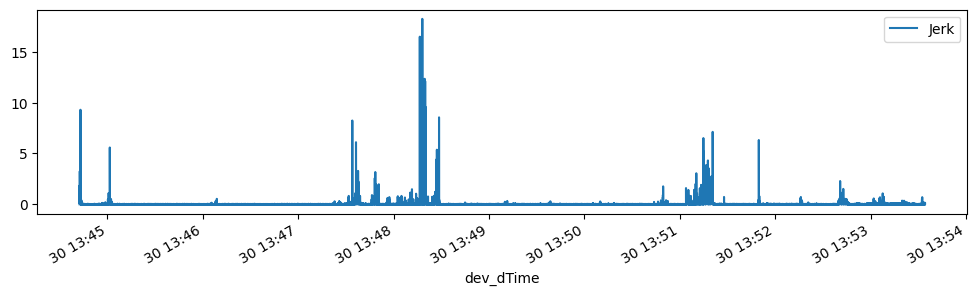

In [274]:
dt_0 = synch_times[c]-pd.to_timedelta(300,unit='s')
dt_1 = synch_times[c]+pd.to_timedelta(300,unit='s')
ACC_ex = al.dt_cut(V,'dev_dTime',dt_0,dt_1)
print(len(ACC_ex))
ACC_ex.plot(x='dev_dTime',y='Jerk',figsize=[12,3])

4025


<Axes: xlabel='dev_dTime'>

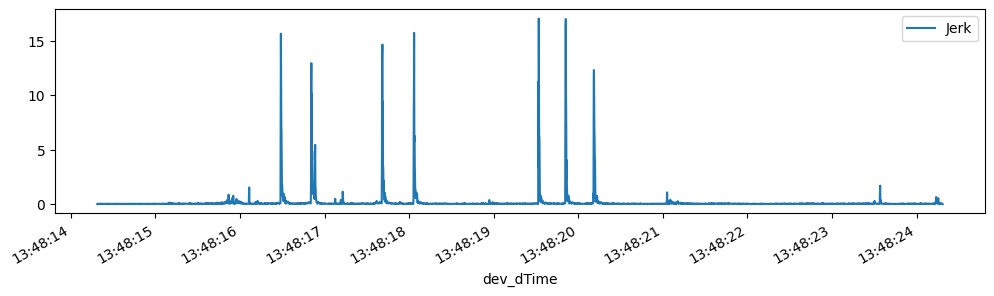

In [278]:
dt_0 = synch_times[c]-pd.to_timedelta(20,unit='s')
dt_1 = synch_times[c]+pd.to_timedelta(-10,unit='s')
ACC_ex = al.dt_cut(V,'dev_dTime',dt_0,dt_1)
print(len(ACC_ex))
ACC_ex.plot(x='dev_dTime',y='Jerk',figsize=[12,3])

In [279]:
to_dev_ts =  -18 # offset in seconds to get the cue closer to true time, incase that is necessary

2025-09-30 13:48:16.310385488


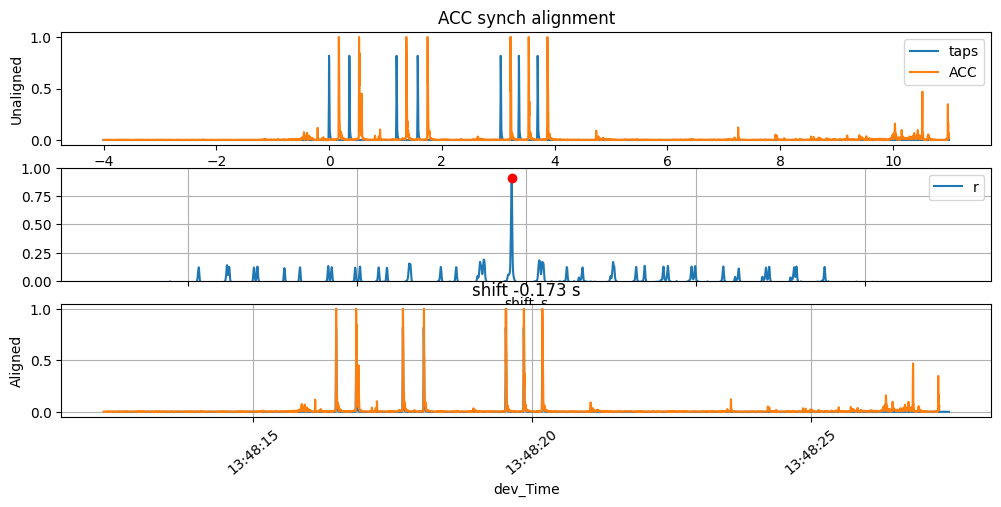

In [280]:
c = 'cue1'
cue = CueT[c].copy()
prelim_synch_time = (synch_times[c]+pd.to_timedelta(to_dev_ts,unit='s')).tz_localize(None)
print(prelim_synch_time)

c_type = 'taps'
results = al.min_align(V,c_type,CueT[c].copy(),prelim_synch_time,10)
Offsets.loc['dev_dt',c]=results['best_dt']

2025-09-30 14:57:56.153650794


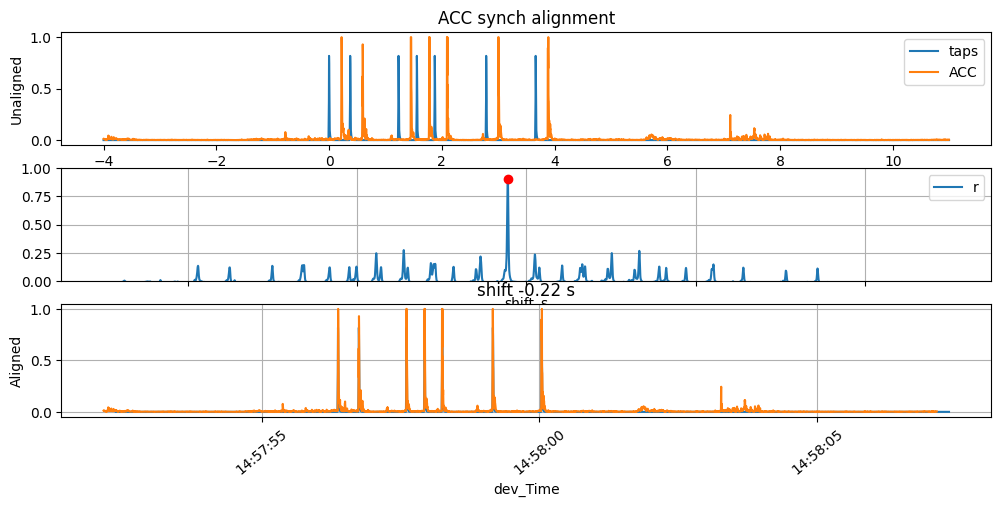

In [281]:
c = 'cue2'
cue = CueT[c].copy()
prelim_synch_time = (synch_times[c]+pd.to_timedelta(to_dev_ts,unit='s')).tz_localize(None)
print(prelim_synch_time)

c_type = 'taps'
results = al.min_align(V,c_type,CueT[c].copy(),prelim_synch_time,10)
Offsets.loc['dev_dt',c]=results['best_dt']

In [282]:
# calculate clock drift constant from the difference between the offsets to sync1 and sync 2
drift_C = (Offsets.loc['exp_dt','cue2']-Offsets.loc['exp_dt','cue1']).total_seconds()/(Offsets.loc['dev_dt','cue2']-Offsets.loc['dev_dt','cue1']).total_seconds()
print(drift_C)
# set zero to the start of the first sync cue
V['rec_sTime'] = 0 +np.round((V['dev_dTime']-Offsets.loc['dev_dt','cue1']).dt.total_seconds()*drift_C,3)
V['rec_dTime'] = pd.to_timedelta(V['rec_sTime'],unit='s')+ Offsets.loc['exp_dt','cue1']
V.iloc[:5,:]

0.9999886360666653


,dev_dTime,X,Y,Z,dev_sTime,Jerk,rec_sTime,rec_dTime
0,2025-09-30 13:42:35.490,-0.187500,0.203125,0.890625,0.000,0.000000,-340.989,2025-09-30 13:42:53.321385488
1,2025-09-30 13:42:35.492,-0.250000,-0.140625,-1.046875,0.002,1.968750,-340.987,2025-09-30 13:42:53.323385488
2,2025-09-30 13:42:35.494,-0.218750,-0.046875,-1.093750,0.004,0.109375,-340.985,2025-09-30 13:42:53.325385488
3,2025-09-30 13:42:35.497,-0.078125,0.031250,-1.046875,0.007,0.167559,-340.982,2025-09-30 13:42:53.328385488
4,2025-09-30 13:42:35.500,0.015625,0.062500,-1.000000,0.010,0.109375,-340.979,2025-09-30 13:42:53.331385488


## Save the new aligned time stamps for the whole file and for an excerpt

- Sync 1, 34.319 s, 13:48 local time
- clapper 1, 2437.788 s,
- Stimulus (applause), 2505.937s
- Stimulus (music), 2528.285
- Stimulus (applause 2), 2822.525
- clapper 2, 2850.388 s,
- clapper 3, 2853.664 s
- Sync 2, 4214.149 s

In [283]:
out_loc = '../Aligned/AX3/'

newfilename = files[dev_i][:5]+'_aligned.csv'
print(newfilename)
V.loc[:,['rec_sTime', 'X', 'Y', 'Z','rec_dTime','dev_dTime']].to_csv(out_loc + newfilename,index=True)

17753_aligned.csv


In [284]:
seg_loc = '../Excerpt/AX3/'

excerpt_start = 2437.788 - 34.319 # time since first sync cue started, the recording time zero
excerpt_end = 2853.664 - 34.319 # time since first sync cue started, the recording time zero
seg = V.query('rec_sTime>@excerpt_start and rec_sTime<@excerpt_end').copy()
seg['p_sTime'] = seg['rec_sTime']-excerpt_start

newfilename = files[dev_i][:5]+'_Seg_aligned.csv'
print(newfilename)
seg.loc[:,['p_sTime', 'X', 'Y', 'Z','rec_sTime','rec_dTime','dev_dTime']].to_csv(seg_loc + newfilename,index=True)      

17753_Seg_aligned.csv


The above sequence can be condensed to run automatically across selected files. Going one at a time is helpful with devices that are more variable than the AX3s. Still it's good to check that the cue template has correctly aligned with the measurements.